In [1]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
file="breastmnist.npz"

In [3]:
data=np.load(file)
data

NpzFile 'breastmnist.npz' with keys: train_images, val_images, test_images, train_labels, val_labels...

In [4]:
x_train,y_train=data['train_images'],data['train_labels']
val_x,val_y=data['val_images'],data['val_labels']
x_test,y_test=data['test_images'],data['test_labels']

In [5]:
x_train = x_train.reshape(-1,28,28,1)
x_val   = val_x.reshape(-1,28,28,1)
x_test  = x_test.reshape(-1,28,28,1)

In [6]:
test_g=ImageDataGenerator(rescale=1./255)
train_g=ImageDataGenerator(zoom_range=0.10,rescale=1./255,rotation_range=20,horizontal_flip=True)
val_g=ImageDataGenerator(rescale=1./255)
train=train_g.flow(x_train,y_train,batch_size=50)
test=test_g.flow(x_test,y_test,batch_size=50)
val=val_g.flow(x_val,val_y,batch_size=50)

In [7]:
print(x_train.shape)

(546, 28, 28, 1)


In [8]:
print(x_test.shape)

(156, 28, 28, 1)


In [10]:
model=Sequential()
model.add(Conv2D(40,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
model.add(Conv2D(120,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(1,activation='sigmoid'))

In [11]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [13]:
history=model.fit(train,validation_data=val,epochs=1000)

Epoch 1/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8443 - loss: 0.3586 - val_accuracy: 0.8590 - val_loss: 0.3893
Epoch 2/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8297 - loss: 0.3593 - val_accuracy: 0.8590 - val_loss: 0.3472
Epoch 3/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8370 - loss: 0.3791 - val_accuracy: 0.8846 - val_loss: 0.3199
Epoch 4/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8535 - loss: 0.3333 - val_accuracy: 0.8590 - val_loss: 0.3789
Epoch 5/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8645 - loss: 0.3363 - val_accuracy: 0.8846 - val_loss: 0.3239
Epoch 6/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8535 - loss: 0.3550 - val_accuracy: 0.8846 - val_loss: 0.3146
Epoch 7/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8535 - loss: 0.3551 - val_accuracy: 0.8718 - val_loss: 0.3306
Epoch 8/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8407 - loss: 0.3594 - val_accu

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 40)     │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 120)    │        43,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 120)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 120)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,165 (547.52 KB)

 Trainable params: 46,721 (182.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 93,444 (365.02 KB)

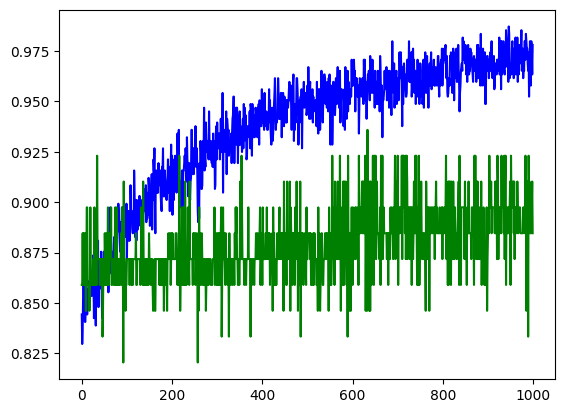

In [15]:
plt.plot(history.history['accuracy'],color='blue',label='accuracy')
plt.plot(history.history['val_accuracy'],color='green',label='val accuracy')

In [16]:
model.save('BreastMNIST.keras')

In [17]:
from tensorflow.keras.models import load_model

model = load_model('BreastMNIST.keras')


In [18]:
test_g = ImageDataGenerator(rescale=1./255)

test = test_g.flow(
    x_test, y_test,
    batch_size=50,
    shuffle=False
)

loss, acc = model.evaluate(test)
print("Test Accuracy:", acc)
print("Test Loss:", loss)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8333 - loss: 0.7514  
Test Accuracy: 0.8333333134651184
Test Loss: 0.751397967338562


In [19]:
y_pred = model.predict(test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [20]:
y_pred_label = (y_pred > 0.5).astype(int)


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_label))
print(classification_report(y_test, y_pred_label))


[[ 21  21]
 [  5 109]]
              precision    recall  f1-score   support

           0       0.81      0.50      0.62        42
           1       0.84      0.96      0.89       114

    accuracy                           0.83       156
   macro avg       0.82      0.73      0.76       156
weighted avg       0.83      0.83      0.82       156



In [25]:
from PIL import Image
import numpy as np

x_sample_path = r"F:\i3.jpg"
img = Image.open(x_sample_path).convert('L')
img = img.resize((28,28))
x_array = np.array(img)/255.0
x_array = x_array.reshape(1,28,28,1)

y_pred = model.predict(x_array)
print("Probability of Malignant:", y_pred[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Probability of Malignant: 0.999999
